# Анализ московского рынка общественного питания

- Автор: Ничкова Анжелика
- Дата: 18.06.2026

## Цели и задачи проекта

Цель: провести исследовательский анализ рынка общественного питания в городе Москва

Задачи:

- Проанализировать структуру данных: определить все категории заведений и их количественное распределение;

- Изучить распределение заведений по административным районам Москвы;

- Рассчитать долю сетевых и несетевых заведений в общем и в разрезе категорий;

- Исследовать распределение посадочных мест, выявить выбросы и определить типичную вместимость для каждой категории;

- Сравнить распределение средних рейтингов по категориям заведений;

- Провести корреляционный анализ различных признаков (район, сеть, места, цены, режим работы) и проверить самую сильную связь;

- Выделить топ-15 крупнейших сетей по количеству точек, оценить их средний рейтинг и категорию;

- Изучить вариацию среднего чека в зависимости от удаленности от центра



## Описание данных

Первый датасет `rest_info` содержит информацию о заведениях общественного питания:

`name` — название заведения;

`address` — адрес заведения;

`district` — административный район, в котором находится заведение, например Центральный административный округ;

`category` — категория заведения, например «кафе», «пиццерия» или «кофейня»;

`hours` — информация о днях и часах работы;

`rating` — рейтинг заведения по оценкам пользователей в Яндекс Картах;

`chain` — число, которое показывает, является ли заведение сетевым:
0 — заведение не является сетевым;
1 — заведение является сетевым.

`seats` — количество посадочных мест.

Второй датасет `rest_price` содержит информацию о среднем чеке в заведениях общественного питания:

`price` — категория цен в заведении;

`avg_bill` — средняя стоимость заказа в виде диапазона;

`middle_avg_bill` — число с оценкой среднего чека, которое указано только для значений из столбца avg_bill;

`middle_coffee_cup` — число с оценкой одной чашки капучино, которое указано только для значений из столбца avg_bill.

## Содержимое проекта

Этапы работы:

- Загрузить и изучить данные

- Проверить типы данных, пропуски и дубликаты

- Провести предобработку данных

- Выполнить задачи, описанные выше (в 1 пункте)

## Загрузка данных и знакомство с ними


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np
!pip install phik -U
from phik import phik_matrix #импорт библиотек

     |████████████████████████████████| 677 kB 2.6 MB/s eta 0:00:01


In [3]:
df_r_inf = pd.read_csv('/datasets/rest_info.csv')
df_r_prc = pd.read_csv('/datasets/rest_price.csv') #выгружаем датасеты

In [4]:
df_r_inf.info()
df_r_inf.head(20) #выводим информацию о первом датасете

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0
5,8a343546b24e4a499ad96eb7d0797a8a,Sergio Pizza,пиццерия,"Москва, Ижорская улица, вл8Б",Северный административный округ,"ежедневно, 10:00–23:00",4.6,0,NaN
6,96ebceb1a09e4e3191133b9fe0379a64,Огни города,"бар,паб","Москва, Клязьминская улица, 9, стр. 3",Северный административный округ,пн 15:00–04:00; вт-вс 15:00–05:00,4.4,0,45.0
7,0243288b78024af090b8e947842c969c,Mr. Уголёк,быстрое питание,"Москва, Клязьминская улица, 9, стр. 3",Северный административный округ,"пн-чт 10:00–22:00; пт,сб 10:00–23:00; вс 10:00...",4.7,0,45.0
8,36aeb0ffa69c48fdb0021549520deb10,Donna Maria,ресторан,"Москва, Дмитровское шоссе, 107, корп. 4",Северный административный округ,"ежедневно, 10:00–22:00",4.8,0,79.0
9,487167877eb04288bc90d4fa80646fc2,Готика,кафе,"Москва, Ангарская улица, 39",Северный административный округ,"ежедневно, 12:00–00:00",4.3,0,65.0


Первый датасет содержит 9 столбцов и 8406 строк. Пропуски обнаружены в столбцах: `hours`, `seats`. Названия столбцов соответсвуют содержанию и прописаны в нужном стиле. Тип данных во всех столбцах соответствует содержанию, кроме столбца `seats`, его мы приведем к целочисленному типу `int64`. Можно предположить причину некорректного типа этого столбца: если в столбцах с целыми числами содержатся пропуски, то тип автоматически меняется на тип данных с плавающей точкой.

In [5]:
df_r_prc.info()
df_r_prc.head(20) # выводим информацию о втором датасете

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN
5,96ebceb1a09e4e3191133b9fe0379a64,средние,Средний счёт:199 ₽,199.0,NaN
6,0243288b78024af090b8e947842c969c,средние,Средний счёт:200–300 ₽,250.0,NaN
7,36aeb0ffa69c48fdb0021549520deb10,средние,Средний счёт:от 500 ₽,500.0,NaN
8,487167877eb04288bc90d4fa80646fc2,средние,Средний счёт:1000–1200 ₽,1100.0,NaN
9,ac32978af97641bfacf996e7f5a50ee5,средние,Цена бокала пива:250–350 ₽,NaN,NaN


Второй датасет содержит 5 столбцов, 4058 строк. Названия столбцов соответсвуют содержанию и прописаны в нужном стиле. Тип данных во всех столбцах соответствует содержанию. Пропуски обнаружены во всех столбцах, кроме столбца `id`.



### Подготовка единого датафрейма


In [6]:
df = df_r_inf.merge(df_r_prc, on='id', how='outer') #соединяем датасеты в один
df.info() #проверим размерность нового датсета

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


Как и ожидалось после соедиенения датасетов, в итоговом датафрейме получилось 8406 строк и 13 столбцов.

In [7]:
temp = df.copy() #сохраним длину исходного датасета для дальнейших проверок
len(temp)

8406

In [8]:
df.dtypes #изучим типы данных

id                    object
name                  object
category              object
address               object
district              object
hours                 object
rating               float64
chain                  int64
seats                float64
price                 object
avg_bill              object
middle_avg_bill      float64
middle_coffee_cup    float64
dtype: object

In [9]:
df['chain'] = pd.to_numeric(df['chain'], downcast='integer') #понизим разрядность в столбцах
for column in ['rating','middle_avg_bill','middle_coffee_cup','seats']:
    df[column] = pd.to_numeric(df[column], downcast='float')

In [10]:
df.dtypes #проверим типы данных

id                    object
name                  object
category              object
address               object
district              object
hours                 object
rating               float32
chain                   int8
seats                float32
price                 object
avg_bill              object
middle_avg_bill      float32
middle_coffee_cup    float32
dtype: object

## Работа с пропусками и дубликатами

In [11]:
df.isna().sum() #выводим абсолютные значения пропусков

id                      0
name                    0
category                0
address                 0
district                0
hours                 536
rating                  0
chain                   0
seats                3611
price                5091
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

In [12]:
display((df.isna().sum()/len(temp))*100) #выводим процент пропусков относительно количества всех строк

id                    0.000000
name                  0.000000
category              0.000000
address               0.000000
district              0.000000
hours                 6.376398
rating                0.000000
chain                 0.000000
seats                42.957411
price                60.563883
avg_bill             54.603854
middle_avg_bill      62.538663
middle_coffee_cup    93.635498
dtype: float64

Пропуски в `seats`: их наличие можно объяснить технической или человеческой ошибкой. Относительное количество пропусков - 42.9% от всех строк.

Пропуски в `hours`, возможно, связаны с тем, что заведение закрыто на ремонт, еще не открылось вовсе или не имеет опредленного графика работы, но технические ошибки также не исключены. Относительное количество пропусков - 6.3% от всех строк.

Столбцы `price`, `avg_bill`, `middle_avg_bill`, `middle_coffee_cup` также содержат пропуски. В `price` их относительное значнеие - 60.5%. Пропуски в остальных столбцах есть, потому что структура данных подразумевает наличие пропусков в них.

In [13]:
df['seats'].max() #найдем максимальное значение столбца, чтобы выбрать число-заглушку

1288.0

In [14]:
df['seats'] = df['seats'].fillna(1300).astype(int) # заполняем пропуски числом заглушкой и меняем тип данных

In [15]:
len(df[df['seats'] == 1300]) # проверим количество повторов числа 1300. оно равнется количеству пропусков в этом столбце.

3611

Так как цель анализа - сравнивать группы между собой, пропуски в других столбцах преобразовывать или удалять мы не будем. Пропусков очень много (40-60%), что делает любое синтетическое заполнение крайне ненадежным и доминирующим в данных.

In [16]:
df.duplicated().sum() #Проверяем данные на наличие явных дубликатов до нормализации

0

In [17]:
cols_to_clean = ['name', 'address'] #цикл нормализует данные к одному регистру и удалит пробелы

for col in cols_to_clean:
    df[col] = df[col].str.lower().str.strip()

In [18]:
dup_names = df[df.duplicated(subset=['name'], keep=False)] # Проверяем на неявные дубликаты по названиям
display(f"Одинаковых названий: {len(dup_names)} записей")

dup_addresses = df[df.duplicated(subset=['address'], keep=False)] # По адресам
display(f"Одинаковых адресов: {len(dup_addresses)} записей")

dup_pair = df[df.duplicated(subset=['name', 'address'], keep=False)] # По паре (название + адрес)
display(f"Одинаковых (название+адрес): 4 записей")

'Одинаковых названий: 3646 записей'

'Одинаковых адресов: 4011 записей'

'Одинаковых (название+адрес): 4 записей'

Обнаружено 4 дублирующихся записей

In [19]:
display(dup_pair)#посмотрим на дубликаты

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
189,072032ce16dc47bfbc63b672c75bd371,кафе,кафе,"москва, парк ангарские пруды",Северный административный округ,"ежедневно, 09:00–23:00",3.2,0,1300,NaN,NaN,NaN,NaN
215,897ddbc6746c4388b19dc8a9fcdbb488,кафе,кафе,"москва, парк ангарские пруды",Северный административный округ,"ежедневно, 10:00–22:00",3.2,0,1300,NaN,NaN,NaN,NaN
1430,62608690e9cc464fbcd980cfd552e334,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",Северный административный округ,"ежедневно, 09:00–21:00",4.2,0,188,NaN,NaN,NaN,NaN
1511,a69f018d5c064873a3b491b0121bc1b4,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",Северный административный округ,"пн-чт 09:00–18:00; пт,сб 09:00–21:00; вс 09:00...",4.2,1,188,NaN,NaN,NaN,NaN
2211,c6ef39ae8a8c483d8f9a6531bc386a2c,раковарня клешни и хвосты,ресторан,"москва, проспект мира, 118",Северо-Восточный административный округ,"ежедневно, 12:00–00:00",4.4,0,150,NaN,NaN,NaN,NaN
2420,aba1de7ad7d64ac0a3f8684bda29d905,раковарня клешни и хвосты,"бар,паб","москва, проспект мира, 118",Северо-Восточный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–01:00; вс 12:00...",4.4,1,150,NaN,NaN,NaN,NaN
3091,3c2a73ea79a04be48858fab3685f2f37,хлеб да выпечка,булочная,"москва, ярцевская улица, 19",Западный административный округ,"ежедневно, 09:00–22:00",4.1,1,276,NaN,NaN,NaN,NaN
3109,d3116844e4e048f99614eb30be3214e0,хлеб да выпечка,кафе,"москва, ярцевская улица, 19",Западный административный округ,NaN,4.1,0,276,NaN,NaN,NaN,NaN


In [20]:
df = df.drop_duplicates(subset=['name', 'address', 'category'], keep='first') #удалим их

In [21]:
len(temp) - len(df) #проверим кол-во удаленных строк в датасете

2

Как и ожидалось, было удалено 2 строки, осталось также 2 уникальных. Данные очищены от неявных дубликатов.

In [22]:
df.duplicated().sum() #Проверяем данные на наличие явных дубликатов

0

In [23]:
df['is_24_7'] = (
    df['hours'].str.contains('ежедневно', case=False) & 
    df['hours'].str.contains('круглосуточно', case=False)) #создаем столбец с обозначением 

In [24]:
df['is_24_7'].value_counts() #посмотрим на количество круглосуточных и не круглосуточных заведений

False    7674
True      730
Name: is_24_7, dtype: int64

In [25]:
a, b = len(temp), len(df)                           # Проверим сколько удалено строк датасета
print(" Было строк в исходном датасете", a,
      '\n', "Осталось строк в датасете после обработки", b,
      '\n', "Удалено строк в датасете после обработки", a-b,
      '\n', "Процент потерь", round((a-b)/a*100, 2))

 Было строк в исходном датасете 8406 
 Осталось строк в датасете после обработки 8404 
 Удалено строк в датасете после обработки 2 
 Процент потерь 0.02


---

### Промежуточный вывод


1. Общая информация о данных:

Размер объединенного датасета: 8406 строк

Размер датасета после преобразований: 8402 строк

В датасете представлены данные о заведениях общественного питания округов Москвы. По каждому заведению известны: название, адрес, категория (например, кафе), административный округ, график работы, рейтинг в Яндекс Картах, обозначение сетевого заведения и количество посадочных мест. Также есть ценовая информация: категория цен, текстовое описание среднего чека, числовая оценка среднего чека и числовая оценка стоимости чашки капучино.

2. Типы данных

Были выполнены преобразования типов данных у столбцов: `rating`, `chain` (понижена разрядность до оптимальной), `seats` преобразован в корректный тип для хранения целого числа.

3. Пропуски

Количество пропусков в объединенном датасете: 23337

Пропуски в столбце `seats` были заменены на значение индикатор "1300". В остальных столбцах попуски остались необработанными для корректного анализа. 

4. Дубликаты

Данные были нормализованы и очищены от пробелов. Явных дубликатов не обнаружено. Обнаружено 4 неявных дубликатов.

Удалено строк в датасете после обработки: 2. 
Процент потерь: 0.02

5. Создание доп. столбцов

Был создан столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно. 

6. Состояние данных

Количество строк в итоговом датасете: 8404. Данные готовы к дальнейшему анализу.

##  Исследовательский анализ данных

---

### Задача 1


In [26]:
df['category'].unique() # посмотрим, какие есть категории заведений

array(['кафе', 'ресторан', 'кофейня', 'пиццерия', 'бар,паб',
       'быстрое питание', 'булочная', 'столовая'], dtype=object)

In [27]:
category_table = pd.pivot_table( #создаем сводную таблицу и подсчитаем количество заведений в каждой категории
    df, 
    index='category', 
    values='id', 
    aggfunc='count').reset_index()
category_table.columns = ['Категория', 'Количество']

total = category_table['Количество'].sum() # добавляем столбец с процентами
category_table['Доля_%'] = (category_table['Количество'] / total * 100).round(1)
display(category_table)

,Категория,Количество,Доля_%
0,"бар,паб",765,9.1
1,булочная,256,3.0
2,быстрое питание,603,7.2
3,кафе,2377,28.3
4,кофейня,1413,16.8
5,пиццерия,633,7.5
6,ресторан,2042,24.3
7,столовая,315,3.7


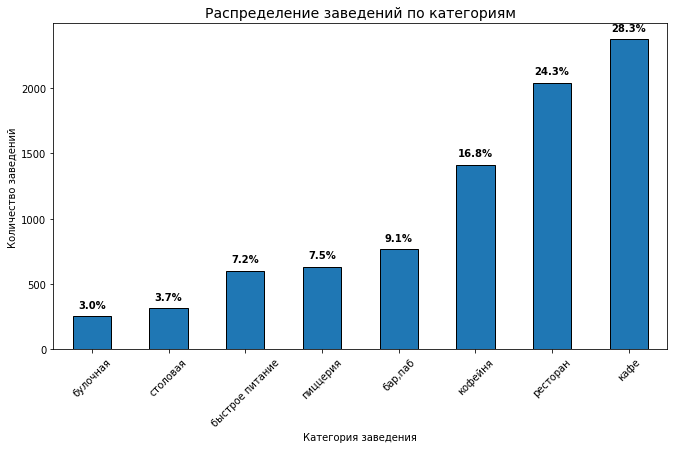

In [28]:
category_table_sorted = category_table.sort_values('Количество', ascending=True) #отсортируем доли
cat_plt = category_table_sorted.plot( # построим столбчатую диаграмму
    kind='bar',
    x='Категория',
    y='Количество',
    legend=False,
    figsize=(11, 6),
    rot=45,
    edgecolor='black'
)

for i, v in enumerate(category_table_sorted['Количество']): #добавим подписи
    percent = category_table_sorted.iloc[i]['Доля_%']  
    cat_plt.text(i, v + max(category_table_sorted['Количество']) * 0.02, 
                 f'{percent}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Распределение заведений по категориям', fontsize=14)
plt.xlabel('Категория заведения')
plt.ylabel('Количество заведений')
plt.show()

Кафе и рестораны суммарно занимают более половины всех заведений (52.5%). Однако, если объединить их с кофейнями и барами, получится, что ~78% точек относятся к форматам, ориентированным на длительное времяпрепровождение (посидеть, поработать, встретиться).


Кафе (28%) и Рестораны (24%) — абсолютные лидеры. 
Кофейни (17%) — третий по величине сегмент, что подтверждает тренд на «кофе с собой» и коворкинг.
Бары (9%) замыкают топ-4, показывая стабильный, но более узкий спрос на вечерний досуг.
Быстрое питание (7%) и Столовые (3.7%) находятся в минорной позиции, что говорит о высокой конкуренции со стороны уличной еды и форматов «готового обеда» в магазинах.


Для массового трафика: открывать кафе (универсальный формат) или кофейню (быстрая окупаемость).


Для высокой маржи: внедрять гибридные форматы (кофейня-пекарня, ресторан-бар), чтобы захватить аудиторию нескольких сегментов.


Если рассматривать столовые, бургерные: выходить в спальные районы с высоким пешеходным трафиком, где спрос на «дешевый обед» остается неудовлетворённым из-за удаленности от офисов.

---

### Задача 2


In [29]:
df['district'].unique() #посмотрим, какие административные районы Москвы присутствуют в данных

array(['Северный административный округ',
       'Северо-Восточный административный округ',
       'Северо-Западный административный округ',
       'Западный административный округ',
       'Центральный административный округ',
       'Восточный административный округ',
       'Юго-Восточный административный округ',
       'Южный административный округ',
       'Юго-Западный административный округ'], dtype=object)

In [30]:
district_table = pd.pivot_table(df, #построим сводную таблицу ко кол-ву заведений в разрезе округов
                                index='district', 
                                values='id', 
                                aggfunc='count').reset_index()
district_table.columns=['Район', 'Количество']

total_d = category_table['Количество'].sum() # добавляем столбец с процентами
district_table['Доля_%'] = (district_table['Количество'] / total_d *100).round(2)
display("Количество заведений по административным округам")
display(district_table)

'Количество заведений по административным округам'

,Район,Количество,Доля_%
0,Восточный административный округ,798,9.50
1,Западный административный округ,851,10.13
2,Северный административный округ,898,10.69
3,Северо-Восточный административный округ,891,10.60
4,Северо-Западный административный округ,409,4.87
5,Центральный административный округ,2242,26.68
6,Юго-Восточный административный округ,714,8.50
7,Юго-Западный административный округ,709,8.44
8,Южный административный округ,892,10.61


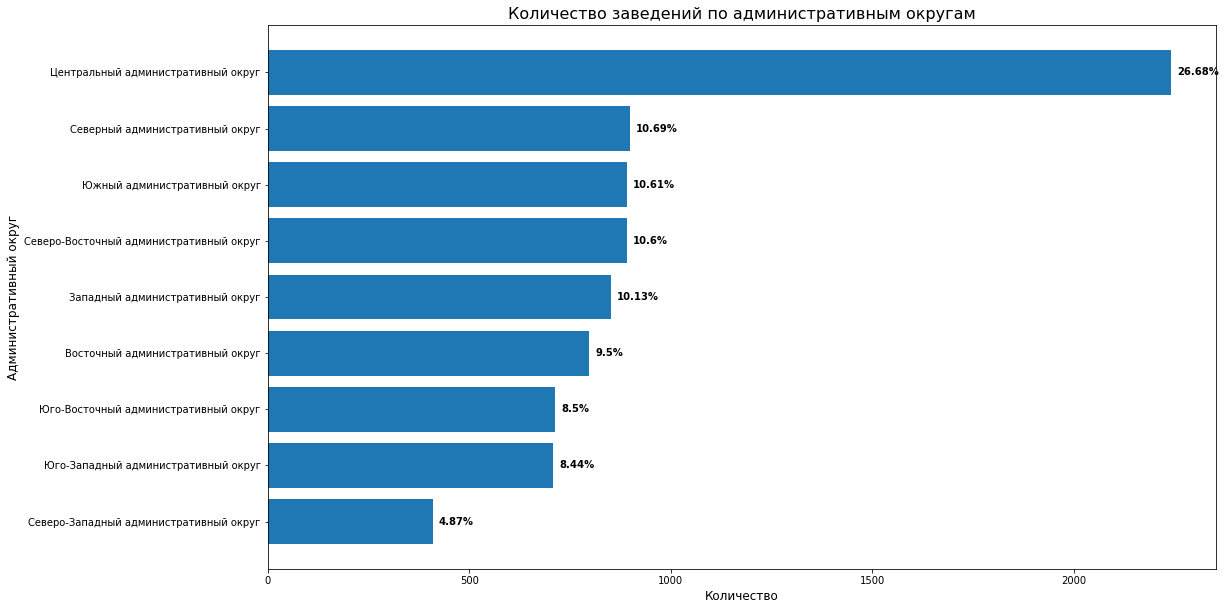

In [31]:
district_table_sorted = district_table.sort_values('Количество', ascending=True) #отсортируем доли

plt.figure(figsize=(17, 10))                        #построим график
bars = plt.barh(district_table_sorted['Район'], 
                district_table_sorted['Количество'])

plt.title('Количество заведений по административным округам', fontsize=16)
plt.xlabel('Количество', fontsize=12)
plt.ylabel('Административный округ', fontsize=12)

for bar, row in zip(bars, district_table_sorted.iterrows()): #сделаем подписи значений
    width = bar.get_width()
    plt.text(
        width + 15,
        bar.get_y() + bar.get_height()/2.,
        f"{row[1]['Доля_%']}%",
        va='center',
        fontsize=10,
        fontweight='bold')
plt.show()

Больше всего заведений сосредоточено в центральном административном округе (26.7%), меньше всего - в Северо-Западном административном округе (4.9%).

In [32]:
cao_df = df[df['district'] == 'Центральный административный округ'] #в новый датафрейм отфильтруем заведения только центрального округа
cao_counts = cao_df['category'].value_counts() #считаем количество заведений в каждой категории

cao_table = pd.pivot_table(cao_df, #построим сводную таблицу ко кол-ву заведений в разрезе центрального округа
                           index='category',
                           values='id', 
                           aggfunc='count').reset_index()
cao_table.columns=['Категория', 'Количество']

total_c = cao_table['Количество'].sum() # добавляем столбец с процентами
cao_table['Доля_%'] = (cao_table['Количество'] / total_c *100).round(2)
display("Количество заведений по категориям в ЦАО") 
display(cao_table)

'Количество заведений по категориям в ЦАО'

,Категория,Количество,Доля_%
0,"бар,паб",364,16.24
1,булочная,50,2.23
2,быстрое питание,87,3.88
3,кафе,464,20.70
4,кофейня,428,19.09
5,пиццерия,113,5.04
6,ресторан,670,29.88
7,столовая,66,2.94


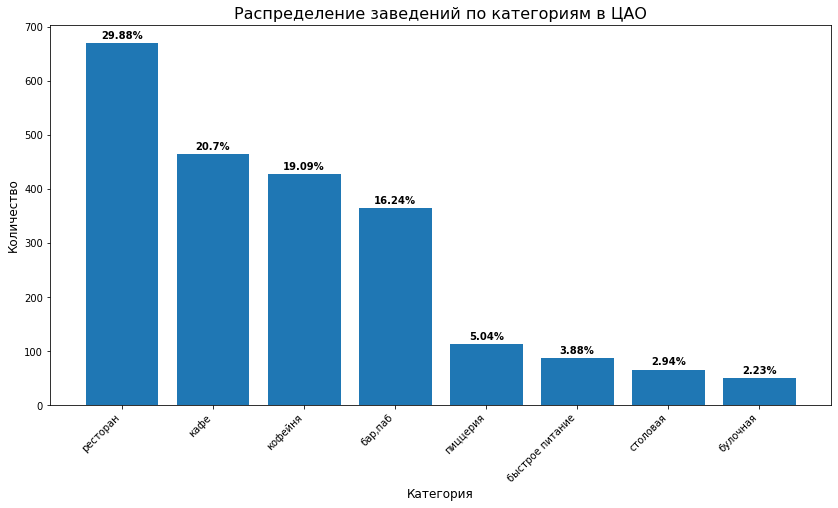

In [33]:
cao_table_sorted = cao_table.sort_values('Количество', ascending=False)  # сортируем по убыванию

plt.figure(figsize=(14, 7))             #построим график
bars = plt.bar(cao_table_sorted['Категория'], 
               cao_table_sorted['Количество'])
plt.title('Распределение заведений по категориям в ЦАО', fontsize=16)
plt.xlabel('Категория', fontsize=12)  
plt.ylabel('Количество', fontsize=12) 
plt.xticks(rotation=45, ha='right')  

for bar, row in zip(bars, cao_table_sorted.iterrows()): #сделаем подписи
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2.,  
        height + 5,  
        f"{row[1]['Доля_%']}%",
        ha='center', 
        va='bottom',
        fontsize=10,
        fontweight='bold')
plt.show()

По графику видно, что в центральном округе больше всего ресторанов.

Сравнивая два графика (распределение категорий по всем округам и в разрезе центрального) можно сделать вывод: в центральном больше всего заведений категории рестораны (29.9%), кафе (20.7%). В разрезе всех округов больше всего: кафе (28.3%), ресторанов (24.3%). Это типичное распределение для центра и окраины, эти округи разные: от контингента до функций этих территорий. Центр — место для «выхода в свет», спальные районы — для повседневной жизни. 

---

### Задача 3


In [34]:
chain_table = pd.pivot_table(df, index='chain', values='id', aggfunc='count').reset_index() #построим таблицу с распределением видов заведений
chain_table.columns=['Вид заведения', 'Количество']
chain_table['Вид заведения'] = chain_table['Вид заведения'].map({0: 'Несетевое', 1: 'Сетевое'}) #поменяем название столбца в таблице
chain_table.columns=['Вид заведения', 'Количество']

total_ch = chain_table['Количество'].sum() # добавляем столбец с процентами
chain_table['Доля_%'] = (chain_table['Количество'] / total_ch *100).round(2)
display("Распределение видов заведений")
display(chain_table)

'Распределение видов заведений'

,Вид заведения,Количество,Доля_%
0,Несетевое,5200,61.88
1,Сетевое,3204,38.12


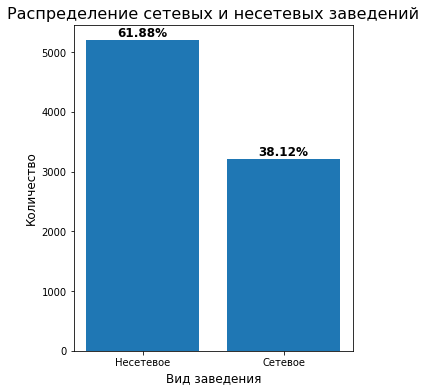

In [35]:
plt.figure(figsize=(5, 6))       #построим график
bars = plt.bar(chain_table['Вид заведения'], 
               chain_table['Количество'])

plt.title('Распределение сетевых и несетевых заведений', fontsize=16)
plt.xlabel('Вид заведения', fontsize=12)
plt.ylabel('Количество', fontsize=12)

for bar, row in zip(bars, chain_table.iterrows()): #добавим подписи
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2.,
        height + 20,
        f"{row[1]['Доля_%']}%",
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold')
plt.show()

Процент несетевых заведений выше. Возможно, это связано с тем, что некоторые категории перенасыщены заведениями похожих форматов, в таких условиях масштабироваться тяжелее. 

,Сетевые,Всего,Доля_сетевых_%
category,,,
булочная,157,256,61.33
пиццерия,330,633,52.13
кофейня,720,1413,50.96
быстрое питание,232,603,38.47
ресторан,729,2042,35.70
кафе,779,2377,32.77
столовая,88,315,27.94
"бар,паб",169,765,22.09


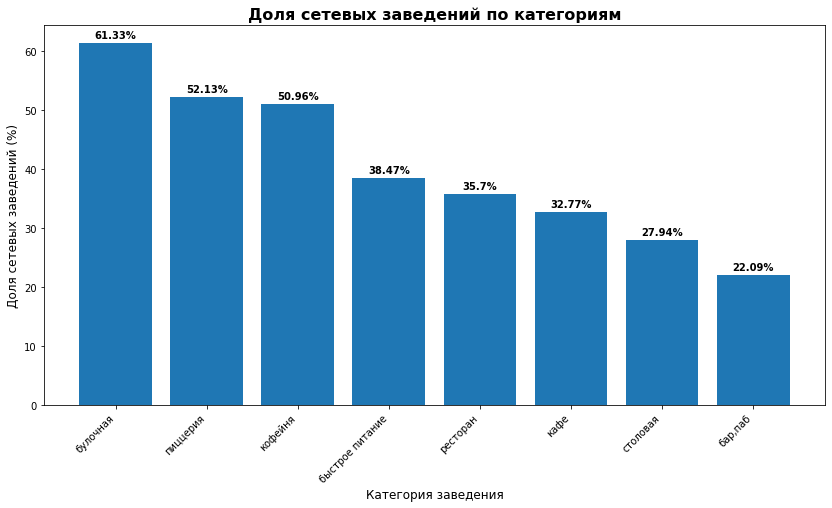

In [36]:
category_chain = pd.pivot_table( #сделаем сводную таблицу по количеству сетевых заведений
    df,
    index='category',
    columns='chain',
    aggfunc='size'
)
category_chain.columns = ['Несетевые', 'Сетевые']

category_chain['Всего'] = category_chain['Сетевые'] + category_chain['Несетевые']
category_chain['Доля_сетевых_%'] = (category_chain['Сетевые'] / category_chain['Всего'] * 100).round(2)

category_chain_sorted = category_chain.sort_values('Доля_сетевых_%', ascending=False) #сортируем по убыванию

plt.figure(figsize=(14, 7))
bars = plt.bar(category_chain_sorted.index,
               category_chain_sorted['Доля_сетевых_%']) #построим график

plt.title('Доля сетевых заведений по категориям', fontsize=16, fontweight='bold')
plt.xlabel('Категория заведения', fontsize=12)
plt.ylabel('Доля сетевых заведений (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')

for bar, (idx, row) in zip(bars, category_chain_sorted.iterrows()): #
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2.,
        height + 0.5,
        f"{row['Доля_сетевых_%']}%",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold')
display(category_chain_sorted[['Сетевые', 'Всего', 'Доля_сетевых_%']])
plt.show()

В булочных, пиццериях и кофейнях больше сетевых заведений. (61.3%, 52.1%, 50,9% соответственно)

Эти сегменты демонстрируют высокий уровень консолидации — более 50% заведений являются сетевыми. Это говорит о том, что рынок уже поделён крупными игроками, а конкуренция строится на узнаваемости бренда и стандартизации сервиса.

Для входа в эти сегменты новым игрокам потребуется либо значительный бюджет на маркетинг, либо уникальная концепция, отличающаяся от существующих сетей. Инвесторам стоит обратить внимание на франшизы в этих категориях — они уже доказали свою жизнеспособность.

---

### Задача 4

Так как пропуски в столбце с посадочными местами были заполнены значением "1300", нужно исключить его из анализа:

In [37]:
# Создаём копию данных без значения индикатора
df_clean = df[df['seats'] != 1300].copy()
# Изучаем сводную статистику
display(df_clean['seats'].describe())

count    4794.000000
mean      108.405090
std       122.840831
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64

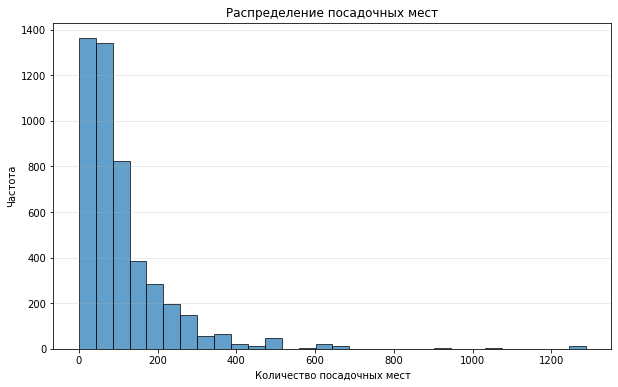

In [38]:
plt.figure(figsize=(10, 6)) #построим гистограмму распределения посадочных мест
plt.hist(df_clean['seats'], bins=30, edgecolor='black', alpha=0.7)
plt.title('Распределение посадочных мест')
plt.xlabel('Количество посадочных мест')
plt.ylabel('Частота')
plt.grid(axis='y', alpha=0.3)
plt.show()

График и сводная статистика показывают: большинство объектов имеют до 100 посадочных мест, с пиком в диапазоне 20–80 мест. С увеличением числа посадочных мест частота резко снижается, а заведения с более чем 200–300 местами встречаются редко, при этом максимальные значения достигают 1000-1288 мест. Таким образом, распределение имеет левостороннюю асимметрию с длинным правым хвостом: преобладают небольшие заведения, а крупных заведений — единицы. Они входят в список аномальных значений. Возможно, это заведения, которые специализируются на крупных мероприятиях и банкетах, либо большие фуд-корты.

In [39]:
pivot_seats_median = pd.pivot_table(df_clean, #построим сводную таблицу с типичным кол-вом посадочных мест
                                    index='category',
                                    values='seats',
                                    aggfunc='median').reset_index()

pivot_seats_median.columns = ['Категория', 'Медианное_количество_посадочных_мест']
pivot_seats_median_sorted = pivot_seats_median.sort_values('Медианное_количество_посадочных_мест', ascending=False) #отсортируем
display(pivot_seats_median_sorted)

,Категория,Медианное_количество_посадочных_мест
6,ресторан,86.0
0,"бар,паб",82.5
4,кофейня,80.0
7,столовая,75.5
2,быстрое питание,65.0
3,кафе,60.0
5,пиццерия,55.0
1,булочная,50.0


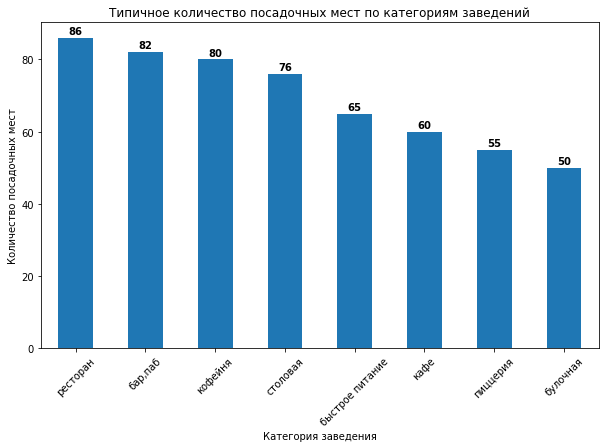

In [40]:
seats_median = df_clean.groupby('category')['seats'].median().round(0).astype(int) #считаем медианное количество посадочных мест в каждой категории
seats_median_sort = seats_median.sort_values(ascending=False)
ax = seats_median_sort.plot(kind='bar',      #строим график
    title='Типичное количество посадочных мест по категориям заведений',
    legend=False,
    xlabel='Категория заведения',
    ylabel='Количество посадочных мест',
    rot=45,
    figsize=(10, 6))

for i, v in enumerate(seats_median_sort): #добавляем подписи значений на столбцы
    ax.text(i, v + 0.5, str(v), ha='center', va='bottom', fontsize=10, fontweight='bold')
    
plt.show()

Анализ показал, что типичное количество посадочных мест самое большое в ресторанах (86), барах (82), кофейнях (80). Самое низкое - в булочных (50). Это значит, что большинство категорий заведений рассчитаны на то, что гости могут продолжительное время находится в заведении. Эти данные могут быть полезны при планировании открытия нового заведения — выбор формата напрямую влияет на требуемую площадь помещения и инвестиции в аренду.

---

### Задача 5

In [41]:
df['rating'].describe()  #изучим сводную статистику по столбцу с рейтингами

count    8404.000000
mean        4.230021
std         0.470270
min         1.000000
25%         4.100000
50%         4.300000
75%         4.400000
max         5.000000
Name: rating, dtype: float64

In [42]:
rating_stats = df.groupby('category')['rating'].describe().reset_index()  #изучим сводную статистику по столбцу с рейтингами
display(rating_stats)                                                           #в разрезе категорий

,category,count,mean,std,min,25%,50%,75%,max
0,"бар,паб",765.0,4.387712,0.380143,1.1,4.3,4.4,4.6,5.0
1,булочная,256.0,4.268360,0.386303,1.3,4.2,4.3,4.4,5.0
2,быстрое питание,603.0,4.050249,0.560949,1.1,3.9,4.2,4.3,5.0
3,кафе,2377.0,4.124274,0.565882,1.0,4.0,4.2,4.4,5.0
4,кофейня,1413.0,4.277282,0.372250,1.4,4.1,4.3,4.4,5.0
5,пиццерия,633.0,4.301264,0.336162,1.0,4.2,4.3,4.4,5.0
6,ресторан,2042.0,4.290401,0.413143,1.0,4.2,4.3,4.5,5.0
7,столовая,315.0,4.211429,0.454205,1.0,4.1,4.3,4.4,5.0


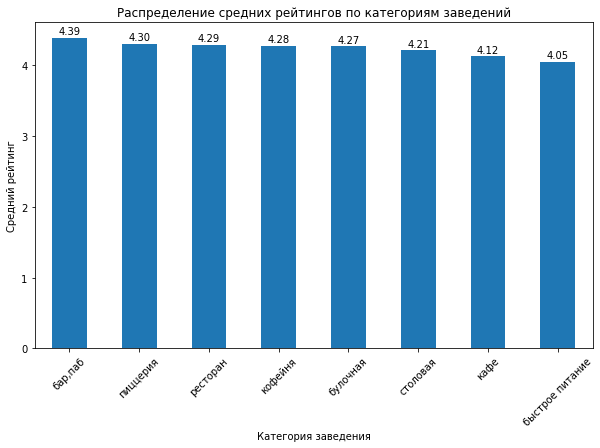

In [43]:
rating_mean = df.groupby('category')['rating'].mean() #считаем средний рейтинг для каждой категории
rating_mean_sorted = rating_mean.sort_values(ascending=False) #сортируем по убыванию
bars = rating_mean_sorted.plot(kind='bar',
                  title='Pаспределение средних рейтингов по категориям заведений', #построим график распределения
                  legend=False,
                  figsize=(10, 6),
                  xlabel='Категория заведения',
                  ylabel='Средний рейтинг',
                  rot=45)
for bar in bars.patches: #добавим подписи для читаемости
    bars.text(
        bar.get_x() + bar.get_width()/2,  
        bar.get_height() + 0.02,          
        f'{bar.get_height():.2f}',         
        ha='center',
        va='bottom',
        fontsize=10
    )
plt.show()

По графику видно, что средние рейтинги не очень различаются, некоторые из них находятся примерно на одном уровне. Стоит отметить, что по рейтингу лидирует паб,бар(4.39), самый низкий рейтинг у быстрого питания(4.06).

Если цель инвестора - максимальная лояльность аудитории, то подойдет формат "бар,паб". Гости заведения такого формата, как правило, лояльнее, чем гости в ресторанах, поэтому рейтинг самый высокий.

Проблема фастфуда и кафе: рынок этих заведений перенасыщен. Средняя оценка 4.05 означает, что около половины точек имеют рейтинг ниже 4.0 — это уровень "можно не прийти" для многих гостей. Открывать кафе или фастфуд без четкого стандарта качества или известного бренда очень рискованно.
Столовые: Не все столовые дешевые и плохие. Огромный разброс данных (от 1.0 до 5.0) говорит о наличии ниши "премиум-столовых" в бизнес-центрах, которые получают оценки на уровне ресторанов.

Рекомендации:

Стоит отдельно изучить бары с рейтингом >4.6 и столовые с рейтингом >4.5, чтобы понять их формулу успеха (меню, акции, расположение).
Избегать "серой зоны": открывать обычное кафе или рядовую бургерную сейчас невыгодно — конкуренция завалила этот сегмент низкими оценками.
Инвестиции в качество: в сегменте "быстрого питания" важна не цена, а стабильность. Учитывая высокий стандартный разброс отметок, заведение с четким сервисом (рейтинг 4.5+) легко вырвется вперед.

---

### Задача 6


interval columns not set, guessing: ['rating', 'chain', 'seats']


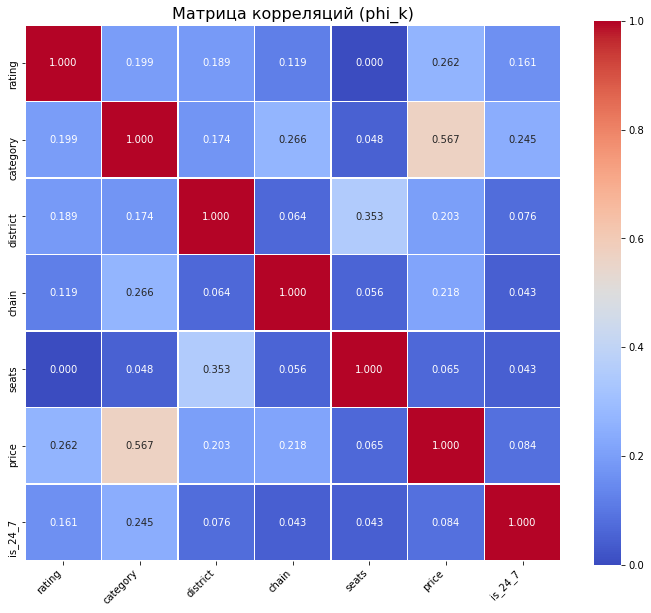

'Корреляции рейтинга с признаками:'

price       0.262
category    0.199
district    0.189
is_24_7     0.161
chain       0.119
seats       0.000
Name: rating, dtype: float64

"Самый сильный признак, коррелирующий с рейтингом: 'price' (phi_k = 0.262)"

In [44]:
df_corr = df.copy() #копируем датафрейм

#восстанавливаем пропуски в seats
df_corr['seats'] = df_corr['seats'].replace(1300, np.nan)

# преобразуем категориальные признаки 
df_corr['category'] = df_corr['category'].astype('category')
df_corr['district'] = df_corr['district'].astype('category')
df_corr['price'] = df_corr['price'].astype('category')

#выбираем столбцы
cols = ['rating', 'category', 'district', 'chain', 'seats', 'price', 'is_24_7']

#считаем матрицу корреляции phi_k
phi_k_matrix = df_corr[cols].phik_matrix().round(3)

# визуализация тепловой карты
plt.figure(figsize=(12, 10))
sns.heatmap(phi_k_matrix, annot=True, cmap='coolwarm', fmt='.3f',
            linewidths=0.5, square=True)
plt.title('Матрица корреляций (phi_k)', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.show()

#извлекаем корреляции рейтинга с другими признаками
rating_corrs = phi_k_matrix['rating'].drop('rating').sort_values(ascending=False)

#выводим таблицу
display("Корреляции рейтинга с признаками:")
display(rating_corrs)

#находим самый сильный признак
strongest_feature = rating_corrs.idxmax()
strongest_value = rating_corrs.max()
display(f"Самый сильный признак, коррелирующий с рейтингом: '{strongest_feature}' (phi_k = {strongest_value:.3f})")

Вывод: рейтинг зависит от того, какая ценовая политика в заведении. Например, чем выше цены, тем рейтинг выше. Это может отражать тот факт, что заведения с более высокими ценами часто ассоциируются с более качественным сервисом и атмосферой, что субъективно повышает оценку. Но, стоит отметить, что коэффициент 0.272 является все равно низким (в сравнении с максимально возможным числом "1") и свидетельствует о слабой положительной связи. То есть при открытии заведения не стоит расчитывать на то, что ценовая политика станет ключевым фактором высокого рейтинга.

На втором месте — категория заведения (0.199), за ней — район расположения (0.189). Эти показатели также очень низкие. Например, разница в рейтинге между барами и фастфудом, которую мы видели ранее, скорее связана с особенностями аудитории и форматом обслуживания, а не с самим фактом принадлежности к категории.

Круглосуточный режим работы (0.161) и сетевой статус (0.119) практически не влияют на оценку. Это означает, что работа 24/7 или принадлежность к известной сети не даёт автоматического преимущества в рейтинге.

Не стоит делать ставку на расположение, ценовую политику или формат если цель - высокий рейтинг. 
Основной ресурс следует направлять на повышение качества сервиса и создание уникального предложения.

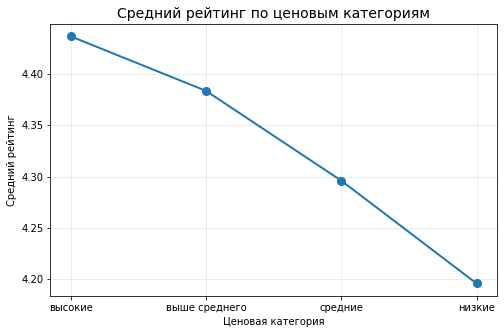

In [45]:
price_order = ['высокие', 'выше среднего', 'средние', 'низкие']
price_rating = df_clean[['price', 'rating']].copy()   # создаём копию нужных колонок
# Преобразуем колонку price в категориальный тип с этим порядком
price_rating['price'] = pd.Categorical(price_rating['price'], categories=price_order, ordered=True)
mean_by_price = price_rating.groupby('price')['rating'].mean()

plt.figure(figsize=(8, 5))
plt.plot(mean_by_price.index, mean_by_price.values, marker='o', linestyle='-', linewidth=2, markersize=8)
plt.title('Средний рейтинг по ценовым категориям', fontsize=14)
plt.xlabel('Ценовая категория')
plt.ylabel('Средний рейтинг')
plt.grid(True, alpha=0.3)
plt.show()

Можно наблюдать чёткий нисходящий тренд: с переходом от более дорогих категорий к более дешёвым средний рейтинг последовательно снижается. Падение рейтинга происходит плавно и почти линейно — между соседними категориями разница составляет примерно 0.05 балла. Это говорит о том, что ценовой фактор оказывает устойчивое, постепенное влияние на оценку, без резких скачков. Для бизнеса это означает, что повышение цен может ассоциироваться у гостей с более высоким качеством, что отражается в рейтингах.

---

### Задача 7


In [46]:
network_df = df[df['chain'] == 1].copy() #фильтруем заведения с признаком "сетевые"

network_counts = network_df.groupby(['name', 'category']).agg( #uруппируем по названию и категории, считаем количество и средний рейтинг
    count_objects=('id', 'count'),
    mean_rating=('rating', 'mean')).reset_index()

network_counts['mean_rating'] = network_counts['mean_rating'].round(6) #oкругляем рейтинг

network_counts_sorted = network_counts.sort_values('count_objects', ascending=False) #сортируем по количеству заведений и берём топ-15
top15_network = network_counts_sorted.head(15)
display("Топ-15 сетевых заведений по количеству объектов:")
display(top15_network)

'Топ-15 сетевых заведений по количеству объектов:'

,name,category,count_objects,mean_rating
1126,шоколадница,кофейня,119,4.178151
496,домино'с пицца,пиццерия,76,4.169737
489,додо пицца,пиццерия,74,4.286486
205,one price coffee,кофейня,71,4.064789
1142,яндекс лавка,ресторан,69,3.872464
72,cofix,кофейня,65,4.075384
241,prime,ресторан,49,4.114286
617,кофепорт,кофейня,42,4.147619
632,кулинарная лавка братьев караваевых,кафе,39,4.394872
963,теремок,ресторан,36,4.105556


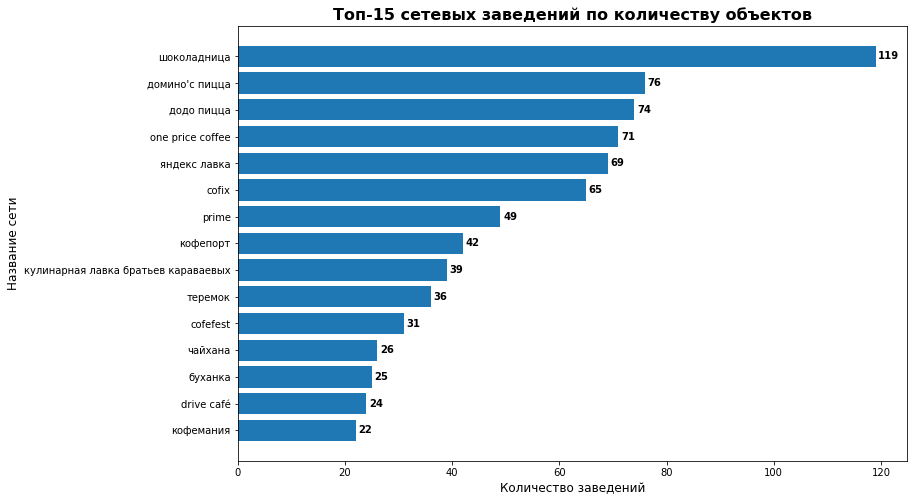

In [47]:
top15_network_sorted = top15_network.sort_values('count_objects', ascending=True) #сортируем

plt.figure(figsize=(12, 8)) #строим график
bars = plt.barh(top15_network_sorted['name'], 
                top15_network_sorted['count_objects'])
plt.title('Топ-15 сетевых заведений по количеству объектов', fontsize=16, fontweight='bold')
plt.xlabel('Количество заведений', fontsize=12)
plt.ylabel('Название сети', fontsize=12)

for bar, (idx, row) in zip(bars, top15_network_sorted.iterrows()): #сделаем подписи
    width = bar.get_width()
    plt.text(
        width + 0.5,
        bar.get_y() + bar.get_height()/2.,
        f'{int(width)}',
        va='center',
        fontsize=10,
        fontweight='bold')
plt.show()

Лидеры по количеству заведенний в сети - "Шоколадница" (119 заведений), "Доминоc пицца" (76), "Додо пицца" (74). Их категории - кофейня и пиццерии соответственно. Стоит отметить, что они не являются лидерами по среднему рейтингу.

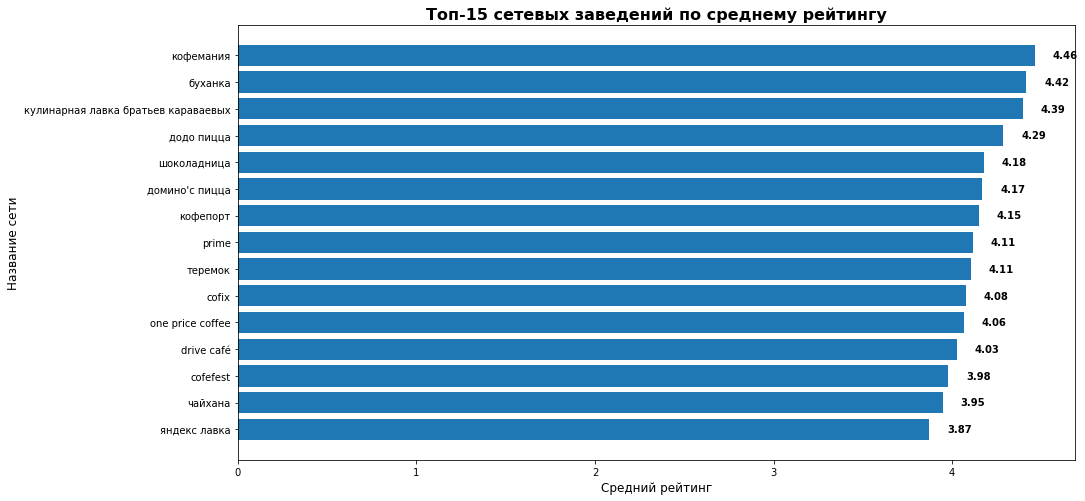

In [48]:
top_network15_rating = top15_network.sort_values('mean_rating', ascending=True) #сортируем
plt.figure(figsize=(15, 8)) #строим график
bars = plt.barh(top_network15_rating['name'], 
                top_network15_rating['mean_rating'])
plt.title('Топ-15 сетевых заведений по среднему рейтингу', fontsize=16, fontweight='bold')
plt.xlabel('Средний рейтинг', fontsize=12)
plt.ylabel('Название сети', fontsize=12)

for bar, (idx, row) in zip(bars, top_network15_rating.iterrows()): #сделаем подписи
    width = bar.get_width()
    plt.text(
        width + 0.1,
        bar.get_y() + bar.get_height()/2.,
         f'{width:.2f}',
        va='center',
        fontsize=10,
        fontweight='bold')
plt.show()

Лидерами по среднему рейтингу являются: Кофемания (4.46), Буханка (4.42), Кулинарная лавка братьев караевых (4.39). Хоть они и не являются лидерами по количеству заведений в сети, стоит обратить особое внимание на их методику ведения бизнеса и способы повышения лояльности гостей. Всем известно, что в Кофемании объективно высокие цены для ассортимента блюд и соответственно, контингент там - люди с высоким достатком. А лояльность таких гостей, как правило, завоевать тяжелее всего. На это стоит обратить внимание при изучении их правил в обслуживании.

Самый низкий рейтинг у Яндекс.Лавки (3.87). Но это неудивительно, ведь это сервис доставки еды, у них совсем другие приоритеты.

---

### Задача 8


In [49]:
df['middle_avg_bill'].describe() #рассмотрим сводную статистику по среднему чеку

count     3149.000000
mean       958.053650
std       1009.732849
min          0.000000
25%        375.000000
50%        750.000000
75%       1250.000000
max      35000.000000
Name: middle_avg_bill, dtype: float64

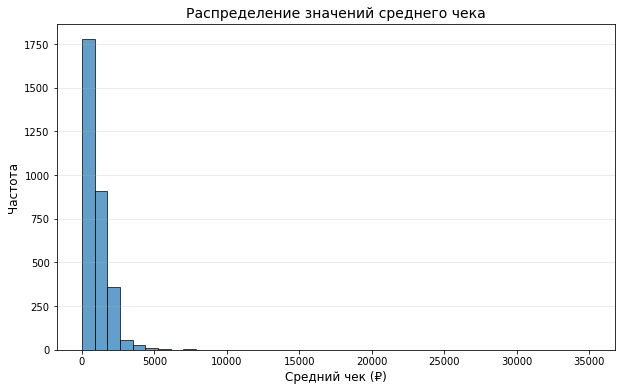

In [50]:
filtered_bills = df['middle_avg_bill']


plt.figure(figsize=(10, 6))
plt.hist(filtered_bills, bins=40, edgecolor='black', alpha=0.7)
plt.title('Распределение значений среднего чека', fontsize=14)
plt.xlabel('Средний чек (₽)', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [51]:
bill_stats = df.groupby('district')['middle_avg_bill'].agg(median='median', #группируем по району и считаем медиану и среднее значение среднего чека
                                                           mean='mean').reset_index()

bill_stats['median'] = bill_stats['median'].round(1) #округляем
bill_stats['mean'] = bill_stats['mean'].round(2)

bill_stats_sorted = bill_stats.sort_values('mean', ascending=False) #сортируем

bill_stats_sorted.columns = ['Район', 'Медиана', 'Среднее']

display("Медиана и среднее значение среднего чека по административным округам:")
display(bill_stats_sorted)

'Медиана и среднее значение среднего чека по административным округам:'

,Район,Медиана,Среднее
5,Центральный административный округ,1000.0,1191.060059
1,Западный административный округ,1000.0,1053.229980
2,Северный административный округ,650.0,927.960022
8,Южный административный округ,500.0,834.400024
4,Северо-Западный административный округ,700.0,822.219971
0,Восточный административный округ,575.0,820.630005
7,Юго-Западный административный округ,600.0,792.559998
3,Северо-Восточный административный округ,500.0,716.609985
6,Юго-Восточный административный округ,450.0,654.099976


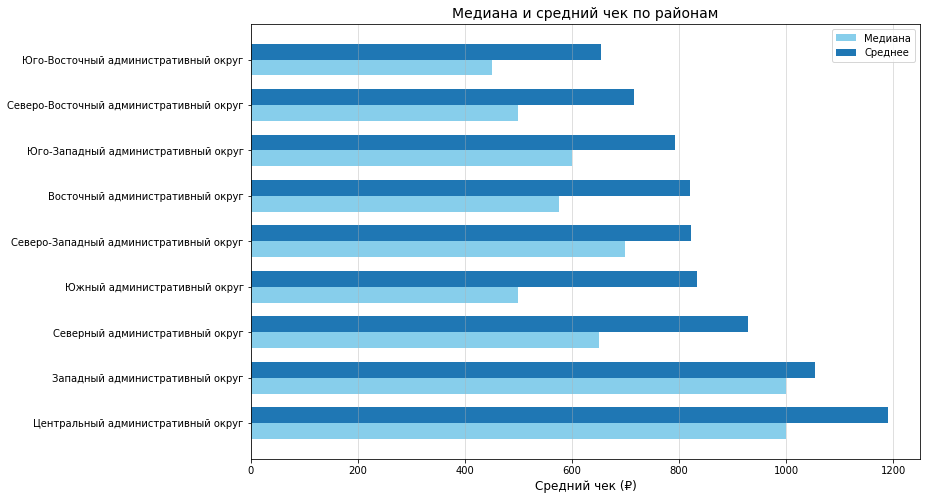

In [52]:
y = list(range(len(bill_stats_sorted)))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 8)) #построим график

bars1 = ax.barh([i - width/2 for i in y], bill_stats_sorted['Медиана'], #создаем 2 ряда столбцов
                height=width, label='Медиана', color='skyblue')
bars2 = ax.barh([i + width/2 for i in y], bill_stats_sorted['Среднее'], 
                height=width, label='Среднее')
ax.set_yticks(y) # Подписи по Y
ax.set_yticklabels(bill_stats_sorted['Район'])
ax.set_xlabel('Средний чек (₽)', fontsize=12)
ax.set_title('Медиана и средний чек по районам', fontsize=14)
ax.grid(axis='x', alpha=0.5)
ax.legend()

plt.show()

Судя по графику, центральный административный округ является лидером среди средних чеков. В западном округе средний чек немного ниже. Но медианные значения среднего чека совпадают. Интересно, что в других округах средние значения имеют не сильный разрыв друг от друга. Медианные значения плавно снижаются к Юго-Восточному округу. Если посмотреть на график с географической точки зрения, можно сделать такой вывод: есть тенденция, что чем дальше округ от центрального, тем меньше сумма медианного чека. Исключением будет Северо-Западный округ. Он находится дальше, чем Северный, но его чек (700 р.) выше, чем у Северного (650 р.).

Влияние удалённости нелинейно:
Ближний пояс (ЗАО): Практически не уступает центру (средний чек — 1053 ₽, медиана — 1000 ₽). Удалённость на 5–10 км от Кремля почти не снижает цену.

Средний пояс (САО, СЗАО, ЮАО, ВАО, ЮЗАО, СВАО): Происходит обвал на 20–35%. Средний чек падает до уровня 715–830 ₽.

Дальний пояс (ЮВАО): Максимальное влияние удалённости. Цены падают до 654 ₽ (средний) и 450 ₽ (медиана). Это почти вдвое ниже, чем в ЦАО.


Бизнес-смысл:
При запуске в ЦАО и ЗАО следует закладывать наценку +30–50% к себестоимости — рынок её примет. В ЮВАО, ЮАО, СВАО полагаться на высокий чек нельзя. Успех решает только проходимость и демократичная цена (ориентир — медиана 450–600 ₽).

Рекомендация:
Если концепция заведения предполагает цену чека выше 1000 ₽, открывайтесь строго в ЦАО или на западе (ЗАО). При запуске в любом другом округе (кроме ЗАО) расчётная цена должна быть не выше 700–800 ₽, иначе заведение проиграет конкурентам по соотношению «цена-качество».

-----

## Промежуточный вывод

1. Структура рынка и категории заведений:

Рынок представлен 8 основными категориями. Абсолютными лидерами по количеству заведений являются «Кафе» (28.3%) и «Рестораны» (24.3%). Это свидетельствует о высокой конкуренции в этих сегментах. Наименее представлены «Булочные» (3%).

2. Географическое распределение (Административные округа):

Наблюдается сильная концентрация заведений в центре. Центральный административный округ (ЦАО) аккумулирует 26.7% всех точек общепита.

В ЦАО, в отличие от города в целом, в структуре заведений доминируют «Рестораны» (29.9%).

3. Сетевые и несетевые заведения:

Несетевые заведения занимают большую часть рынка — 61.9%. Однако, среди определенных категорий сетевое присутствие значительно выше. Булочные, пиццерии и кофейни являются наиболее сетевыми категориями, где доля сетей превышает 50%.

4. Вместимость заведений (Посадочные места):

Распределение посадочных мест имеет левую асимметрию. Большинство заведений имеют до 100 мест, с пиком в диапазоне 20-80 мест.

Самая высокая типичная вместимость (по медиане) у ресторанов (86 мест) и баров (82 места), самая низкая — у булочных (50 мест). Аномально высокие значения (более 300 мест) являются редкими и, вероятно, относятся к крупным банкетным залам или фуд-кортам.

5. Рейтинги заведений:

Средние рейтинги по категориям различаются незначительно, колеблясь в узком диапазоне от 4.05 до 4.39.

Самый высокий средний рейтинг у баров (4.39), а самый низкий — у заведений быстрого питания (4.05). Это говорит о том, что в целом пользователи оценивают заведения общепита достаточно схоже.

6. Корреляция рейтинга с другими факторами:

Самой сильной (хотя и слабой) оказалась связь с ценовой категорией (price, = 0.262). На втором месте — категория заведения (0.199), затем район (0.189). Все коэффициенты крайне низки, что говорит о том, что ни один из изученных объективных факторов не является определяющим для рейтинга. Анализ среднего рейтинга по ценовым категориям показывает чёткую положительную зависимость: чем выше ценовой сегмент, тем выше средняя оценка заведений.

7. Топ-15 сетевых заведений:

Крупнейшими сетями по количеству точек являются «Шоколадница» (119), «Домино'с Пицца» (76) и «Додо Пицца» (74). Их категории — преимущественно кофейни и пиццерии. При этом, размер сети не гарантирует высокий рейтинг. Лидером в среднем рейтинге стала "Кофемания".

8. Средний чек в зависимости от района:

Существует четкая тенденция снижения медианного чека по мере удаления от центра города.

Наивысший медианный чек (1000 руб.) зафиксирован в Центральном и Западном округах. В самых отдаленных (Юго-Восточный) округах медианный чек в два раза ниже (450 руб.). Исключение составляет Северо-Западный округ, который демонстрирует более высокий чек, чем Северный, что может быть связано с иной ценовой политикой или концепцией заведений.

## Итоговый вывод и рекомендации

---

1. Обзор работы

Мы проанализировали рынок общественного питания Москвы на основе открытых данных Яндекс Карт. В работу вошли 8406 заведений с информацией о категории, районе, рейтинге, количестве мест, сетевом статусе, ценовом сегменте и режиме работы. Данные были очищены от пропусков, проверены на дубликаты и приведены к единому формату. Мы исследовали структуру рынка, географию, популярность сетей и факторы, влияющие на рейтинг и средний чек.

2. Главные выводы исследования

На рынке доминируют две категории — кафе (28.3%) и рестораны (24.3%). Это самые насыщенные сегменты с высокой конкуренцией. При этом в Центральном округе, где сосредоточено 26.7% всех заведений, структура смещается в сторону ресторанов (29.9%), что отличает центр от остальных районов. Меньше всего точек общепита в Северо-Западном округе — всего 4.9%.

Сетевые и несетевые форматы:

Несетевые заведения составляют большинство — 61.9%. Однако в некоторых категориях сетевой формат преобладает. Например, булочные (61.3% сетевых). Это говорит о том, что для такого формата заведений открыто уже достаточно большое количество. Категории, где несетевой формат явно преобладает:

бары и пабы — 22.1% сетевых; столовые — 27.9%; кафе — 32.8%; рестораны — 35.7%.

Вместимость заведений:

Типичное количество посадочных мест (медиана) варьируется:

Рестораны — 86 мест; Бары — 82 места; Булочные — 50 мест

Аномально большие значения (свыше 300 мест) встречаются редко и, скорее всего, относятся к банкетным залам или крупным фуд-кортам. Основная масса заведений имеет до 100 мест, а пик приходится на диапазон 20–80 мест.

Рейтинги:

Средние рейтинги по категориям различаются слабо. Самый высокий средний рейтинг у баров (4.39), самый низкий — у быстрого питания (4.05). В целом оценки пользователей находятся в узком промежутке — от 4.0 до 4.4. Это может свидетельствовать о том, что формат заведения не играет ключевую роль.

Факторы, влияющие на рейтинг:

Корреляционный анализ показал, что рейтинг не имеет сильной связи ни с одним из изученных факторов. Самую сильную (но всё равно слабую) связь показала ценовая категория (φ_k = 0.262), за ней следуют категория заведения (0.199) и район (0.189). Все коэффициенты ниже 0.3, что означает: ни цена, ни расположение, ни формат, ни другие формальные параметры не предопределяют высокий рейтинг. Основное влияние на оценки оказывают неучтённые в данных факторы — качество обслуживания, вкус еды, атмосфера, уникальность концепции. Но, между ценовой политикой заведения и его средним рейтингом есть устойчивая связь: чем выше ценовая категория, тем выше средняя оценка. Самые дорогие места получают около 4,38 балла, бюджетные — около 4,23, разница примерно в 0,15 балла, и она плавно прослеживается через все ступени. Это значит, что в среднем люди оценивают более дорогие заведения чуть выше, но причина не в самой цене, а в том, что за высокой ценой обычно стоят лучший сервис. Ценовая политика работает только в связке с реальным качеством, и точечные инвестиции в клиентский опыт окупаются в рейтингах быстрее, чем простое изменение ценника.

Топ-15 сетей:

Крупнейшие сети по числу точек:

«Шоколадница» — 119 заведений; «Домино'с Пицца» — 76 заведений; «Додо Пицца» — 74 заведения

При этом размер сети не гарантирует высокий рейтинг. Например, «Буханка» (25 точек) имеет рейтинг 4.42, а «Кофемания» (22 точки) — 4.46, что выше, чем у многих более крупных сетей.

Средний чек и удалённость от центра:

Здесь прослеживается чёткая закономерность: чем дальше от центра, тем ниже медианный чек.

В Центральном и Западном округах медианный чек — 1000 руб; в Северном — уже 650 руб; в Юго-Восточном — 450 руб.

Исключение — Северо-Западный округ (700 руб.), который находится дальше Северного, но показывает более высокий чек. Возможно, это связано с особенностями локального спроса или иной структурой заведений.

Рекомендации:

Выход в сегменты «кафе» и «рестораны» требует сильного уникального предложения, так как эти категории уже перенасыщены. Более перспективными могут быть «булочные» или «столовые», где конкуренция ниже — это позволяет быстрее масштабироваться.

При выборе локации можно ориентироваться на ценовую политику района. В центре можно устанавливать более высокие цены, но и конкуренция там выше. В других районах заведения должны быть более доступны.

Хотя ценовая категория демонстрирует самую сильную (но всё равно слабую) связь с рейтингом, полагаться только на ценообразование для повышения оценок не стоит. Тем не менее, ключевой драйвер рейтинга — качество сервиса. 

Не стоит переоценивать влияние «внешних» факторов, таких как количество мест или круглосуточный режим. Как показал анализ, нельзя зацикливаться на них, лучше направить силы на повышение лояльности и узнаваемости, потому что во многих категориях заведений конкуренция может быть высокая.